 # Phoneme Replacement Structure in L2-ARCTIC



 Goal:

 Show that phoneme substitutions are not random, but are related to

 articulatory-feature similarity.



 Main outputs:

 1. Substitution confusion heatmap

 2. Observed substitution-distance distribution

 3. Observed vs null distance comparison

 4. Distance-bin substitution plot

 5. Feature-retention / feature-change summaries

 6. Canonical-phone "family" summaries for realised substitutions



 Notes:

 - Correct phones are kept as type='c'

 - add/del are collapsed into substitution-style events using SIL

 - SIL is excluded from articulatory-distance calculations

 - PanPhon feature vectors are used for feature-wise analysis



 This script is designed to be thesis-friendly:

 it prioritizes interpretable plots over overly clever pair-level regressions.

In [1]:
import os
import re
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from textgrid import TextGrid, IntervalTier
from sklearn.metrics import confusion_matrix
from scipy.stats import ks_2samp, mannwhitneyu, spearmanr, pearsonr

import panphon
from phonecodes import phonecodes

from src.utils.load_l2arctic import load_all_scripted

sns.set(style="whitegrid")
warnings.filterwarnings("ignore")


In [2]:
OUT_DIR = Path("./phoneme_replacement_structure_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SIL = "SIL"


 ## Load data

In [3]:
dataset = load_all_scripted()
dataset_df = pd.DataFrame(dataset)

dataset_df = dataset_df[
    dataset_df["annotation"].notnull() &
    (dataset_df["annotation"] != "None")
].copy()

print(f"Loaded {len(dataset_df)} annotated utterances.")
print(dataset_df[["utterance_id", "speaker", "l1", "text", "annotation"]].head())


Loading scripted utterances from 18 speakers: 100%|██████████| 18/18 [01:44<00:00,  5.81s/it]


[load_train_dev_utterances]  train=17306  dev=3055  held_out_l1=None


Loading scripted utterances from 6 speakers: 100%|██████████| 6/6 [00:30<00:00,  5.14s/it]

[load_cmu_arctic_utterances] 1132 utterances from 1 speakers
[load_test_utterances] 7638 utterances total
Loaded 3599 annotated utterances.
    utterance_id speaker       l1  \
2   arctic_a0048    TXHC  Chinese   
6   arctic_a0104    YKWK   Korean   
7   arctic_a0041     ASI    Hindi   
11  arctic_a0233   MBMPS  Spanish   
50  arctic_b0527     NCC  Chinese   

                                                 text  \
2          He looked at the handkerchief more closely   
6   She was sleeping under his protection as sweet...   
7            Meanwhile I'll go out to breathe a spell   
11    I never allow what can't be changed to annoy me   
50                   Very idea of it was preposterous   

                                           annotation  
2   data/l2_arctic/TXHC/annotation/arctic_a0048.Te...  
6   data/l2_arctic/YKWK/annotation/arctic_a0104.Te...  
7   data/l2_arctic/ASI/annotation/arctic_a0041.Tex...  
11  data/l2_arctic/MBMPS/annotation/arctic_a0233.T...  
50  data/l2_ar

 ## Helpers

In [4]:
def clean_phone(p):
    """
    Normalize raw phone token:
    - uppercase
    - remove whitespace, trailing punctuation, stress/index markers, star
    - collapse pause/silence variants to SIL
    """
    if pd.isna(p):
        return None


    s = str(p).strip().upper()
    s = s.rstrip(",")
    s = s.replace(")", "")
    s = s.replace("(", "")
    s = re.sub(r"\s+", "", s)
    s = re.sub(r"[\d\*\_\`]+$", "", s)

    if s in {"", "ERR", "NONE"}:
        return None
    if s in {"SP", "SIL", "PAU", "SPN", "NSN"}:
        return SIL

    return s


def parse_phone_tier(tier: IntervalTier):
    """
    Parse phone tier entries of form: 'CPL,PPL,type'

    New behavior:
    - correct phones: keep ref == hyp and type='c'
    - substitutions: keep type='s'
    - deletions: convert to substitution with hyp=SIL
    - additions: convert to substitution with ref=SIL
    """
    rows = []

    for interval in tier:
        mark = interval.mark.strip()
        if not mark:
            continue

        parts = [p.strip() for p in mark.split(",")]

        if len(parts) == 1:
            # Correct phone
            p = clean_phone(parts[0])
            ref = hyp = p
            typ = out_type = "c"

        elif len(parts) == 3:
            cpl, ppl, typ = parts
            ref = clean_phone(cpl)
            hyp = clean_phone(ppl)
            typ = typ.lower().strip()

            if typ == "s":
                if ref is None or hyp is None:
                    continue
                out_type = "s"

            elif typ == "d":
                # deletion => treat as substitution to silence
                if ref is None:
                    continue
                hyp = SIL
                out_type = "s"

            elif typ == "a":
                # addition => treat as substitution from silence
                if hyp is None:
                    continue
                ref = SIL
                out_type = "s"
            else:
                continue

        else:
            print(f"Unexpected mark format: '{mark}' in tier '{tier.name}'")
            continue

        rows.append({
            "start": interval.minTime,
            "end": interval.maxTime,
            "ref": ref,
            "hyp": hyp,
            "type": out_type,
            "orig_type": typ
        })

    return rows


def safe_load_textgrid(file_path):
    try:
        tg = TextGrid.fromFile(file_path)
        global_xmax = tg.maxTime
        for tier in tg:
            if hasattr(tier, "maxTime") and tier.maxTime > global_xmax:
                tier.maxTime = global_xmax
            if hasattr(tier, "xmin") and tier.xmin < tg.xmin:
                tier.xmin = tg.xmin
        return tg
    except Exception as e:
        print(f"Failed {file_path}: {e}")
        return None


def load_phone_events_from_textgrids(df, annt_col="annotation"):
    rows = []

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        annt_file = row[annt_col]
        if pd.isna(annt_file) or not os.path.exists(annt_file):
            continue

        tg = safe_load_textgrid(annt_file)
        if tg is None:
            continue

        phone_tier = None
        for tier in tg:
            if tier.name.strip().lower() in {"phones", "phone"}:
                phone_tier = tier
                break
        if phone_tier is None and len(tg) > 1:
            phone_tier = tg[1]

        if phone_tier is None:
            continue

        phone_rows = parse_phone_tier(phone_tier)

        for r in phone_rows:
            r["speaker"] = row.get("speaker", "unknown")
            r["l1"] = row.get("l1", "unknown")
            r["utt_id"] = row.get("utterance_id", idx)
            r["text"] = row.get("text", "")

        rows.extend(phone_rows)

    return pd.DataFrame(rows)


def clean_arpabet(p):
    p = clean_phone(p)
    if p is None or p == SIL:
        return None
    return p


def arpabet_to_ipa_single(p):
    p = clean_arpabet(p)
    if p is None:
        return None

    try:
        ipa = phonecodes.arpabet2ipa(p, "eng")
    except Exception:
        try:
            ipa = phonecodes.convert(p, "arpabet", "ipa", "eng")
        except Exception:
            return None

    if ipa is None:
        return None

    ipa = ipa.strip().replace("ˈ", "").replace("ˌ", "").replace(" ", "")
    return ipa or None



In [5]:
df_phones = load_phone_events_from_textgrids(dataset_df)

print(df_phones.head())
print(df_phones["type"].value_counts(dropna=False))
print(df_phones["orig_type"].value_counts(dropna=False))


  7%|▋         | 252/3599 [00:02<00:28, 116.65it/s]

Failed data/l2_arctic/YDCK/annotation/arctic_a0272.TextGrid: 2.22363


 74%|███████▍  | 2679/3599 [00:24<00:08, 104.40it/s]

Failed data/l2_arctic/YDCK/annotation/arctic_a0209.TextGrid: 3.55456


100%|██████████| 3599/3599 [00:31<00:00, 113.30it/s]

   start   end ref hyp type orig_type speaker       l1        utt_id  \
0   0.00  0.10  HH  HH    c         c    TXHC  Chinese  arctic_a0048   
1   0.10  0.17  IY  IY    c         c    TXHC  Chinese  arctic_a0048   
2   0.17  0.29   L   L    c         c    TXHC  Chinese  arctic_a0048   
3   0.29  0.35  UH  UH    c         c    TXHC  Chinese  arctic_a0048   
4   0.35  0.45   K   K    c         c    TXHC  Chinese  arctic_a0048   

                                         text  
0  He looked at the handkerchief more closely  
1  He looked at the handkerchief more closely  
2  He looked at the handkerchief more closely  
3  He looked at the handkerchief more closely  
4  He looked at the handkerchief more closely  
type
c    113588
s     18339
Name: count, dtype: int64
orig_type
c    113588
s     13838
d      3420
a      1081
Name: count, dtype: int64


 ## Prepare substitution table

In [6]:
all_events = df_phones.copy()

subs = all_events[
    (all_events["type"] == "s") &
    (all_events["ref"] != all_events["hyp"])
].copy()

subs["ref_clean"] = subs["ref"].map(clean_arpabet)
subs["hyp_clean"] = subs["hyp"].map(clean_arpabet)

# Keep segmental substitutions only for articulatory analysis
subs_seg = subs.dropna(subset=["ref_clean", "hyp_clean"]).copy()

print(f"All substitution-like events (incl SIL-based add/del): {len(subs)}")
print(f"Segmental substitutions with clean phones: {len(subs_seg)}")


All substitution-like events (incl SIL-based add/del): 17223
Segmental substitutions with clean phones: 12722


 ## Build PanPhon feature table once

In [7]:
ft = panphon.FeatureTable()

phones_for_features = sorted(set(subs_seg["ref_clean"]) | set(subs_seg["hyp_clean"]))

feature_rows = []
for p in phones_for_features:
    ipa = arpabet_to_ipa_single(p)
    if ipa is None:
        continue
    try:
        segs = ft.word_to_vector_list(ipa, numeric=True)
        names = ft.names
        if segs:
            vec = np.array(segs[0], dtype=float)
            feature_rows.append({
                "phone": p,
                "ipa": ipa,
                "vec": vec
            })
    except Exception:
        pass

feat_map = {r["phone"]: r["vec"] for r in feature_rows}
ipa_map = {r["phone"]: r["ipa"] for r in feature_rows}
feature_names = list(ft.names)

print(f"Phones with feature vectors: {len(feat_map)}")
print("Example features:", feature_names[:10])


Phones with feature vectors: 38
Example features: ['syl', 'son', 'cons', 'cont', 'delrel', 'lat', 'nas', 'strid', 'voi', 'sg']


In [47]:
subs_seg = subs_seg[
    subs_seg["ref_clean"].isin(feat_map) &
    subs_seg["hyp_clean"].isin(feat_map)
].copy()

# Pair counts
pair_counts = (
    subs_seg.groupby(["ref_clean", "hyp_clean"])
    .size()
    .reset_index(name="count")
)

# Canonical counts over all outcomes (correct + substitution), segmental only
all_events["ref_clean"] = all_events["ref"].map(clean_arpabet)
all_events["hyp_clean"] = all_events["hyp"].map(clean_arpabet)

canonical_totals = (
    all_events[all_events["ref_clean"].isin(feat_map)]
    .groupby("ref_clean")
    .size()
)

# Distance and feature summary per pair
pair_rows = []
for _, row in pair_counts.iterrows():
    ref = row["ref_clean"]
    hyp = row["hyp_clean"]
    ref_vec = feat_map[ref]
    hyp_vec = feat_map[hyp]

    absdiff = np.abs(ref_vec - hyp_vec)
    changed = absdiff > 0

    pair_rows.append({
        "ref": ref,
        "hyp": hyp,
        "ref_ipa": ipa_map[ref],
        "hyp_ipa": ipa_map[hyp],
        "count": int(row["count"]),
        "dist": float(absdiff.sum()),
        "n_changed_features": int(changed.sum()),
        "pair_prob_all_ref": float(row["count"] / canonical_totals[ref]) if canonical_totals[ref] > 0 else np.nan
    })

pair_df = pd.DataFrame(pair_rows)
pair_df = pair_df.sort_values("count", ascending=False)

print(f"{len(pair_df)} unique segmental substitution pairs")
display(pair_df.head(20))

# pair_df.to_csv(OUT_DIR / "substitution_pairs_with_distance.csv", index=False)


390 unique segmental substitution pairs


,ref,hyp,ref_ipa,hyp_ipa,count,dist,n_changed_features,pair_prob_all_ref
378,Z,S,z,s,1700,2.0,1,0.433563
109,DH,D,ð,d,1676,4.0,2,0.459934
171,IH,IY,ɪ,i,855,2.0,1,0.113125
249,OW,AO,oʊ,ɔ,389,2.0,1,0.205494
262,P,B,p,b,257,2.0,1,0.109782
103,D,T,d,t,249,2.0,1,0.044560
23,AH,AO,ʌ,ɔ,248,4.0,2,0.022754
348,V,F,v,f,245,2.0,1,0.098910
234,N,NG,n,ŋ,244,9.0,5,0.032964
222,L,W,l,w,244,17.0,9,0.051444


 ## Plot 1: substitution confusion heatmap



 This is the best first figure:

 it shows that substitutions are structured, not diffuse/random.

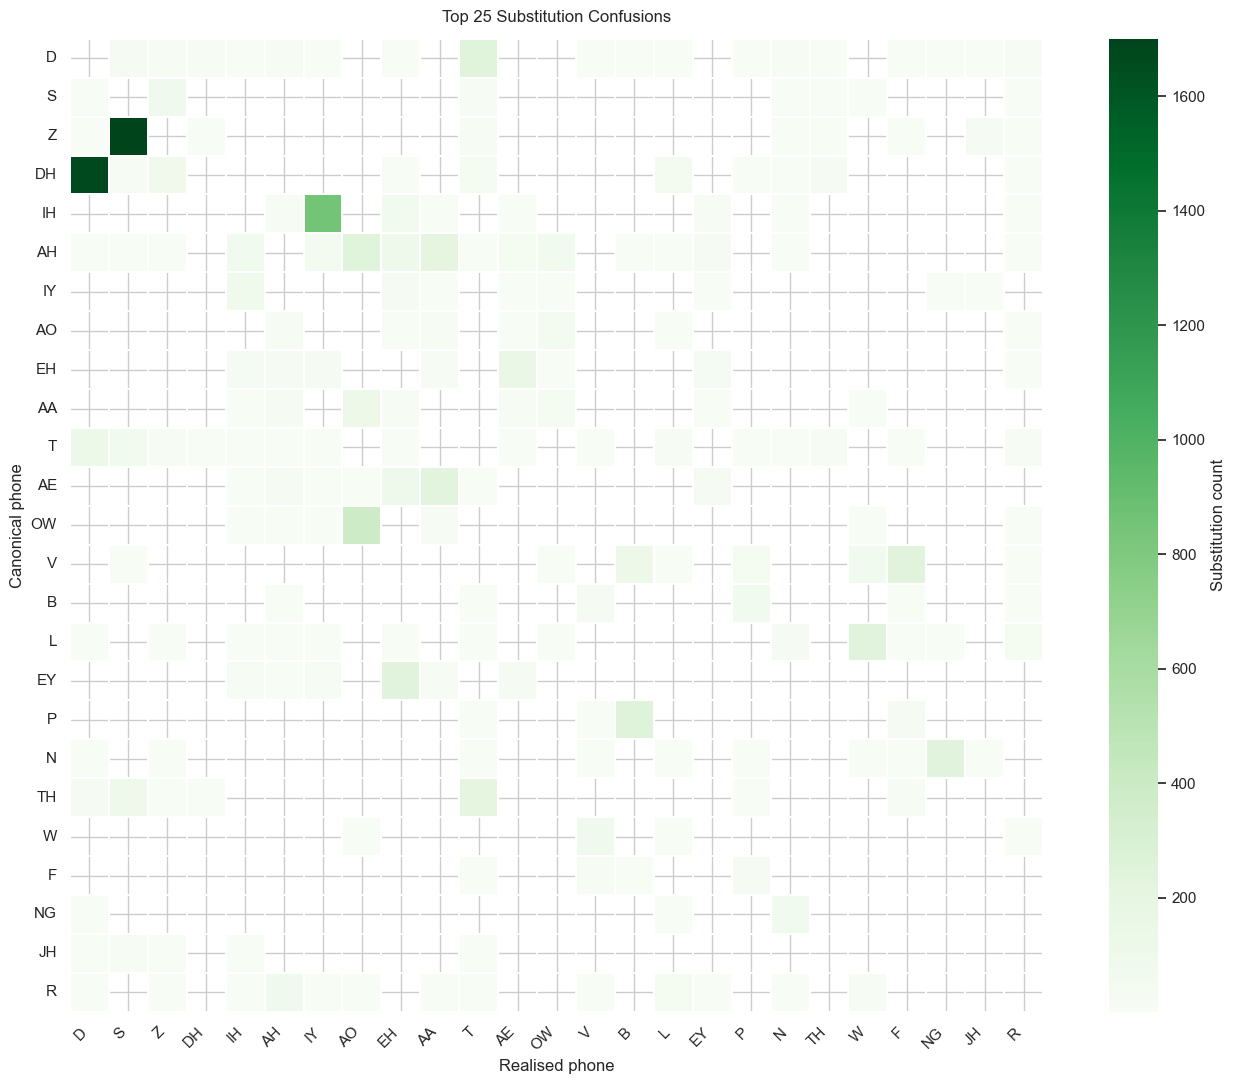

In [48]:
phones = sorted(set(pair_df["ref"]) | set(pair_df["hyp"]))

cm = confusion_matrix(
    pair_df.loc[pair_df.index.repeat(pair_df["count"]), "ref"],
    pair_df.loc[pair_df.index.repeat(pair_df["count"]), "hyp"],
    labels=phones
)

cm_df = pd.DataFrame(cm, index=phones, columns=phones)

conf_mass = cm_df.sum(axis=1) + cm_df.sum(axis=0)
phone_order = conf_mass.sort_values(ascending=False).index.tolist()
cm_ord = cm_df.loc[phone_order, phone_order]

K = min(25, len(cm_ord))
cm_top = cm_ord.iloc[:K, :K].copy()
for i in range(min(cm_top.shape)):
    cm_top.iat[i, i] = np.nan
cm_top = cm_top.replace(0, np.nan)

plt.figure(figsize=(14, 11))
ax = sns.heatmap(
    cm_top,
    cmap="Greens",
    square=True,
    linewidths=0.25,
    linecolor="white",
    cbar_kws={"label": "Substitution count"}
)
ax.set_title(f"Top {K} Substitution Confusions", pad=12)
ax.set_xlabel("Realised phone")
ax.set_ylabel("Canonical phone")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "01_substitution_confusion_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


 ## Plot 2: observed distance distribution



 If substitutions are constrained by articulatory similarity, observed

 substitutions should be concentrated at lower feature distances.

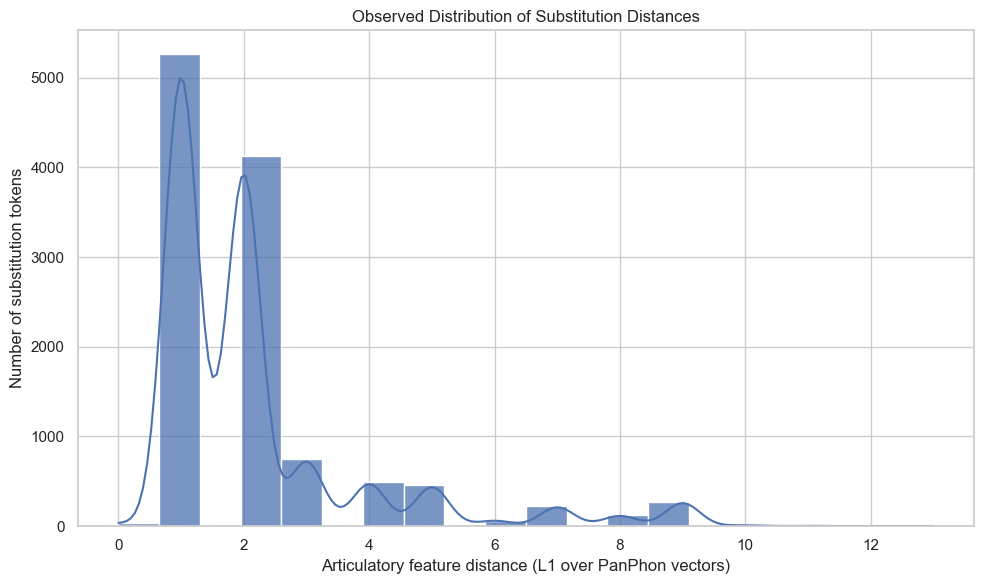

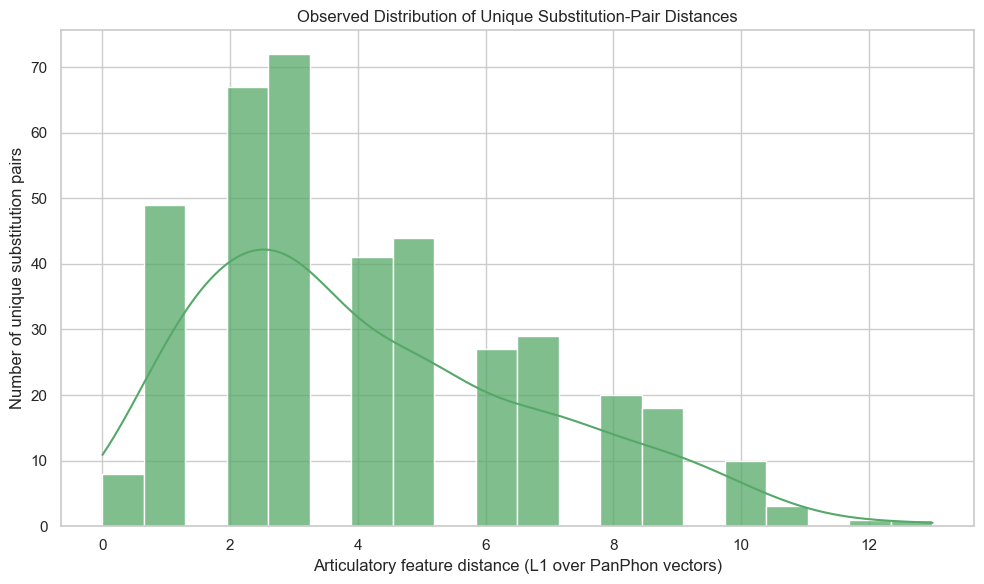

In [49]:
token_level_dist = pair_df.loc[pair_df.index.repeat(pair_df["count"]), "n_changed_features"].reset_index(drop=True)
unique_pair_dist = pair_df["n_changed_features"].copy()

plt.figure(figsize=(10, 6))
sns.histplot(token_level_dist, bins=20, kde=True, color="#4C72B0", alpha=0.75)
plt.xlabel("Articulatory feature distance (L1 over PanPhon vectors)")
plt.ylabel("Number of substitution tokens")
plt.title("Observed Distribution of Substitution Distances")
plt.tight_layout()
# plt.savefig(OUT_DIR / "02_observed_distance_distribution_tokens.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(unique_pair_dist, bins=20, kde=True, color="#55A868", alpha=0.75)
plt.xlabel("Articulatory feature distance (L1 over PanPhon vectors)")
plt.ylabel("Number of unique substitution pairs")
plt.title("Observed Distribution of Unique Substitution-Pair Distances")
plt.tight_layout()
# plt.savefig(OUT_DIR / "03_observed_distance_distribution_unique_pairs.png", dpi=300, bbox_inches="tight")
plt.show()


 ## Plot 3: observed vs null distance distribution



 Strongest figure for the non-randomness claim.



 Null:

 - keep the same phone inventory

 - sample random ref-hyp phone pairs (excluding identity)

 - compare their distances to the observed substitution-pair distances



 This asks:

 Are observed substitution pairs closer than arbitrary cross-phone pairs?

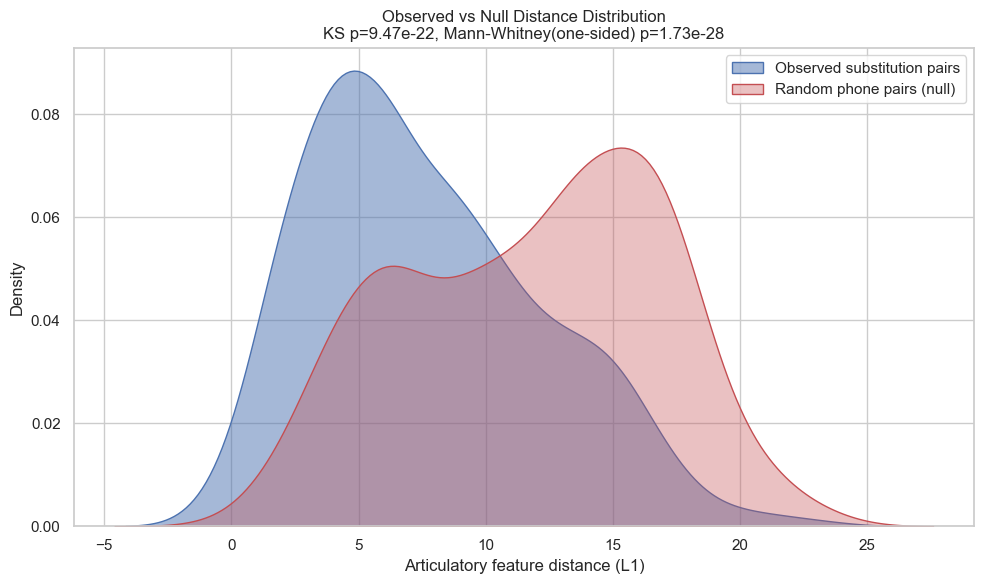

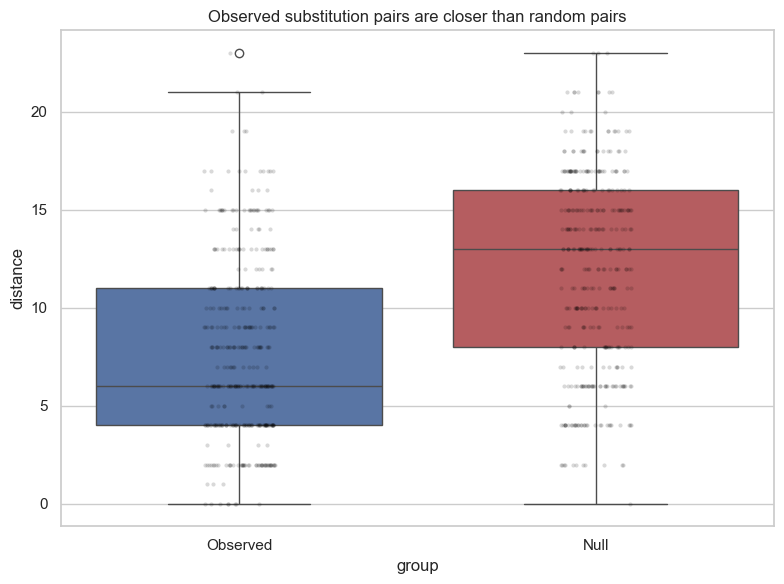

In [54]:
inventory = sorted(set(pair_df["ref"]) | set(pair_df["hyp"]))

all_possible_pairs = []
for ref in inventory:
    for hyp in inventory:
        if ref != hyp:
            if ref in feat_map and hyp in feat_map:
                dist = np.abs(feat_map[ref] - feat_map[hyp]).sum()
                all_possible_pairs.append((ref, hyp, dist))

all_possible_df = pd.DataFrame(all_possible_pairs, columns=["ref", "hyp", "dist"])

observed_unique = pair_df["dist"].to_numpy()
rng = np.random.default_rng(42)

null_unique = all_possible_df.sample(
    n=len(observed_unique),
    replace=False if len(all_possible_df) >= len(observed_unique) else True,
    random_state=42
)["dist"].to_numpy()

ks_stat, ks_p = ks_2samp(observed_unique, null_unique)
mw_stat, mw_p = mannwhitneyu(observed_unique, null_unique, alternative="less")

plt.figure(figsize=(10, 6))
sns.kdeplot(observed_unique, fill=True, label="Observed substitution pairs", color="#4C72B0", alpha=0.5)
sns.kdeplot(null_unique, fill=True, label="Random phone pairs (null)", color="#C44E52", alpha=0.35)
plt.xlabel("Articulatory feature distance (L1)")
plt.ylabel("Density")
plt.title(
    "Observed vs Null Distance Distribution\n"
    f"KS p={ks_p:.3g}, Mann-Whitney(one-sided) p={mw_p:.3g}"
)
plt.legend()
plt.tight_layout()
# plt.savefig(OUT_DIR / "04_observed_vs_null_distance_kde.png", dpi=300, bbox_inches="tight")
plt.show()

# Optional boxplot version
plt.figure(figsize=(8, 6))
box_df = pd.DataFrame({
    "distance": np.concatenate([observed_unique, null_unique]),
    "group": (["Observed"] * len(observed_unique)) + (["Null"] * len(null_unique))
})
sns.boxplot(data=box_df, x="group", y="distance", palette=["#4C72B0", "#C44E52"])
sns.stripplot(data=box_df.sample(min(800, len(box_df)), random_state=42),
              x="group", y="distance", color="black", alpha=0.15, size=3)
plt.title("Observed substitution pairs are closer than random pairs")
plt.tight_layout()
# plt.savefig(OUT_DIR / "05_observed_vs_null_distance_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()


 ## Plot 4: distance-bin substitution trend



 This is a cleaner version of the "distance relationship" idea:

 - x = distance bin

 - y = number of observed unique substitution pairs in that bin



 It avoids misleading pair-probability interpretations.

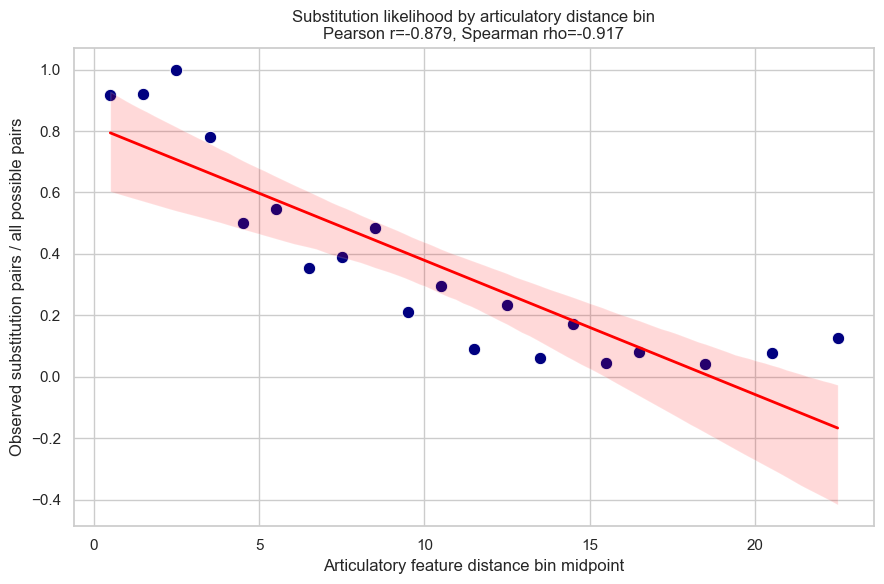

In [55]:
bin_width = 1.0
bins = np.arange(0, max(pair_df["dist"].max(), all_possible_df["dist"].max()) + bin_width, bin_width)

pair_df["dist_bin"] = pd.cut(pair_df["dist"], bins=bins, include_lowest=True)
all_possible_df["dist_bin"] = pd.cut(all_possible_df["dist"], bins=bins, include_lowest=True)

obs_bin = pair_df.groupby("dist_bin").size().reset_index(name="observed_unique_pairs")
null_bin = all_possible_df.groupby("dist_bin").size().reset_index(name="all_possible_pairs")

dist_bin_df = obs_bin.merge(null_bin, on="dist_bin", how="left")
dist_bin_df["dist_mid"] = dist_bin_df["dist_bin"].apply(lambda x: x.mid)
dist_bin_df["obs_over_possible"] = dist_bin_df["observed_unique_pairs"] / dist_bin_df["all_possible_pairs"]

# Correlations
valid = dist_bin_df.dropna(subset=["dist_mid", "obs_over_possible"])
pear_r, pear_p = pearsonr(valid["dist_mid"], valid["obs_over_possible"])
spear_rho, spear_p = spearmanr(valid["dist_mid"], valid["obs_over_possible"])

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=dist_bin_df,
    x="dist_mid",
    y="obs_over_possible",
    s=80,
    color="navy"
)
sns.regplot(
    data=dist_bin_df,
    x="dist_mid",
    y="obs_over_possible",
    scatter=False,
    color="red",
    line_kws={"lw": 2}
)
plt.xlabel("Articulatory feature distance bin midpoint")
plt.ylabel("Observed substitution pairs / all possible pairs")
plt.title(
    "Substitution likelihood by articulatory distance bin\n"
    f"Pearson r={pear_r:.3f}, Spearman rho={spear_rho:.3f}"
)
plt.tight_layout()
# plt.savefig(OUT_DIR / "06_distance_bin_ratio_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# dist_bin_df.to_csv(OUT_DIR / "distance_bin_counts_and_ratios.csv", index=False)


 ## Plot 5: feature retention and change



 This directly addresses whether substitutions preserve many articulatory

 properties. For each feature dimension:

 - retention rate = proportion of substitution tokens where ref and hyp

   have the same value on that feature

 - change rate = proportion where that feature differs

,feature,same_weighted,different_weighted
2,cg,1.000000,0.000000
14,long,1.000000,0.000000
10,hitone,1.000000,0.000000
22,velaric,1.000000,0.000000
17,sg,1.000000,0.000000
9,hireg,1.000000,0.000000
15,nas,0.991708,0.008292
20,syl,0.984432,0.015568
18,son,0.964549,0.035451
12,lat,0.960572,0.039428


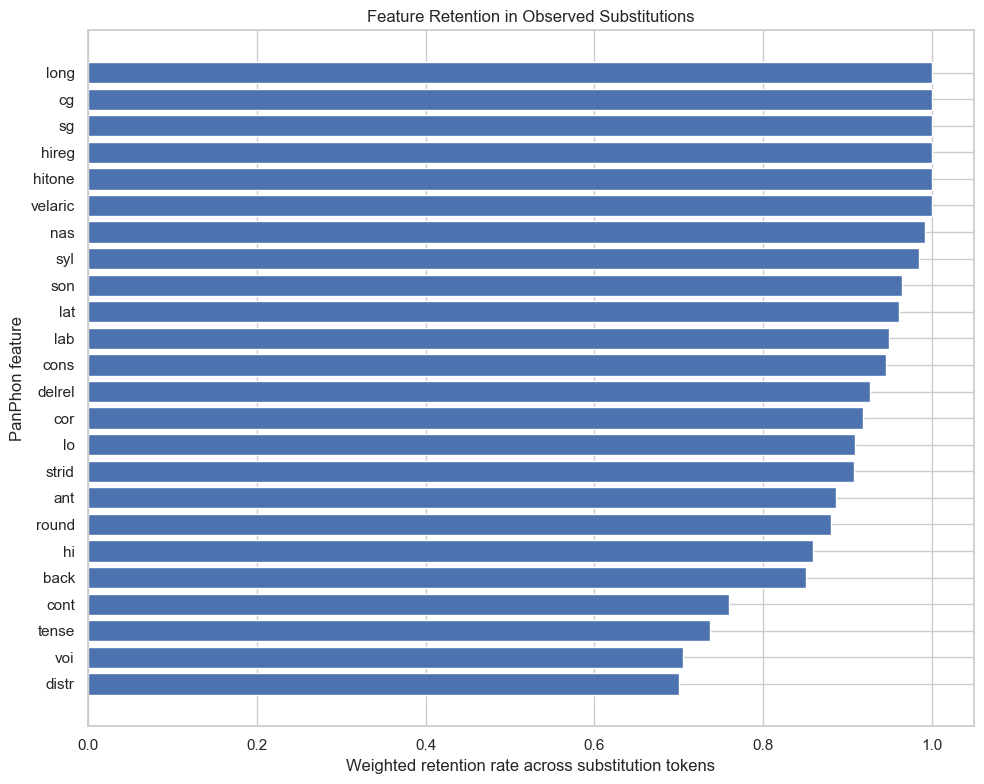

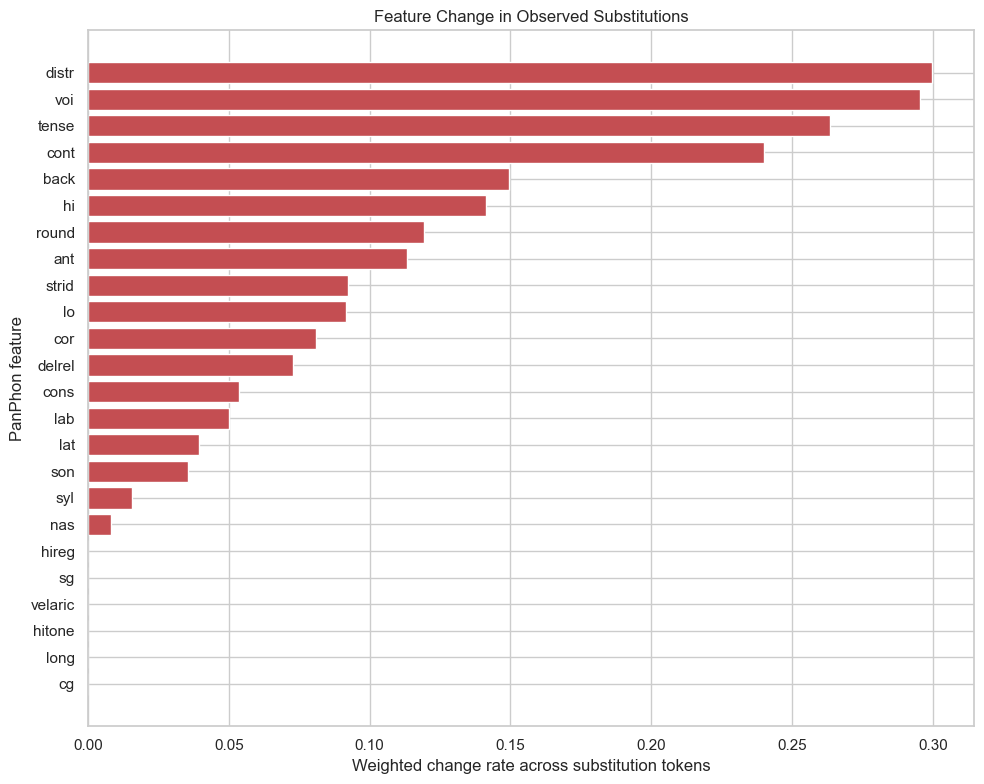

In [13]:
feature_change_rows = []

for _, row in pair_df.iterrows():
    ref = row["ref"]
    hyp = row["hyp"]
    count = row["count"]
    ref_vec = feat_map[ref]
    hyp_vec = feat_map[hyp]

    for i, fname in enumerate(feature_names):
        same = int(ref_vec[i] == hyp_vec[i])
        feature_change_rows.append({
            "feature": fname,
            "same": same,
            "different": 1 - same,
            "weight": count
        })

feature_change_df = pd.DataFrame(feature_change_rows)

feature_summary = (
    feature_change_df.groupby("feature")
    .apply(lambda g: pd.Series({
        "same_weighted": np.average(g["same"], weights=g["weight"]),
        "different_weighted": np.average(g["different"], weights=g["weight"])
    }))
    .reset_index()
    .sort_values("same_weighted", ascending=False)
)

display(feature_summary.head(20))
# feature_summary.to_csv(OUT_DIR / "feature_retention_summary.csv", index=False)

plt.figure(figsize=(10, 8))
plot_df = feature_summary.sort_values("same_weighted", ascending=True)
plt.barh(plot_df["feature"], plot_df["same_weighted"], color="#4C72B0")
plt.xlabel("Weighted retention rate across substitution tokens")
plt.ylabel("PanPhon feature")
plt.title("Feature Retention in Observed Substitutions")
plt.tight_layout()
# plt.savefig(OUT_DIR / "07_feature_retention_barh.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 8))
plot_df = feature_summary.sort_values("different_weighted", ascending=True)
plt.barh(plot_df["feature"], plot_df["different_weighted"], color="#C44E52")
plt.xlabel("Weighted change rate across substitution tokens")
plt.ylabel("PanPhon feature")
plt.title("Feature Change in Observed Substitutions")
plt.tight_layout()
# plt.savefig(OUT_DIR / "08_feature_change_barh.png", dpi=300, bbox_inches="tight")
plt.show()


 ## Plot 6: canonical-phone family summaries



 For each canonical phone:

 - how many distinct realised substitutions does it have?

 - how dispersed are those realised phones in feature space?



 This supports the claim that substitution families are structured.

,ref,total_sub_tokens,n_distinct_realised_subs,dominant_realisation,dominant_share,mean_distance_from_ref,mean_pairwise_dispersion
9,DH,1918,13,D,0.873827,4.132430,4.932351
36,Z,1774,14,S,0.958286,2.158963,6.638347
15,IH,992,11,IY,0.861895,2.267137,4.455657
2,AH,933,20,AO,0.265809,3.911040,5.984628
33,V,497,10,F,0.492958,4.820926,9.315626
23,OW,443,11,AO,0.878104,2.279910,5.571841
1,AE,405,10,AA,0.585185,3.377778,5.739979
30,TH,369,9,T,0.579946,4.265583,4.317363
8,D,365,24,T,0.682192,3.671233,8.290952
11,EY,340,8,EH,0.714706,2.305882,4.462880


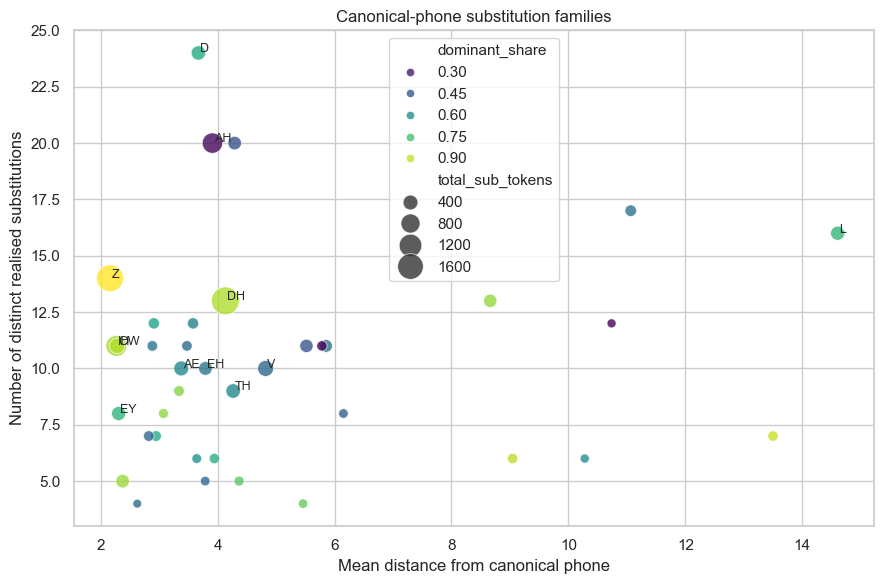

In [14]:
family_rows = []

for ref_phone, group in subs_seg.groupby("ref_clean"):
    realised_counts = group["hyp_clean"].value_counts()
    realised_probs = realised_counts / realised_counts.sum()

    realised_phones = realised_counts.index.tolist()
    realised_weights = realised_counts.values.astype(float)

    # weighted mean distance from canonical phone
    dists_from_ref = [np.abs(feat_map[ref_phone] - feat_map[h]).sum() for h in realised_phones]
    mean_dist_from_ref = np.average(dists_from_ref, weights=realised_weights)

    # weighted pairwise dispersion among realised phones
    pair_dists = []
    pair_w = []
    for i in range(len(realised_phones)):
        for j in range(i + 1, len(realised_phones)):
            d = np.abs(feat_map[realised_phones[i]] - feat_map[realised_phones[j]]).sum()
            w = realised_weights[i] * realised_weights[j]
            pair_dists.append(d)
            pair_w.append(w)

    mean_dispersion = np.average(pair_dists, weights=pair_w) if len(pair_dists) > 0 else np.nan

    family_rows.append({
        "ref": ref_phone,
        "total_sub_tokens": int(realised_counts.sum()),
        "n_distinct_realised_subs": int(len(realised_phones)),
        "dominant_realisation": realised_counts.index[0],
        "dominant_share": float(realised_probs.iloc[0]),
        "mean_distance_from_ref": float(mean_dist_from_ref),
        "mean_pairwise_dispersion": float(mean_dispersion) if not np.isnan(mean_dispersion) else np.nan
    })

family_df = pd.DataFrame(family_rows).sort_values("total_sub_tokens", ascending=False)
display(family_df.head(20))
# family_df.to_csv(OUT_DIR / "canonical_phone_substitution_families.csv", index=False)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=family_df,
    x="mean_distance_from_ref",
    y="n_distinct_realised_subs",
    size="total_sub_tokens",
    hue="dominant_share",
    palette="viridis",
    sizes=(40, 400),
    alpha=0.8
)
for _, row in family_df.nlargest(12, "total_sub_tokens").iterrows():
    plt.text(
        row["mean_distance_from_ref"] + 0.03,
        row["n_distinct_realised_subs"] + 0.03,
        row["ref"],
        fontsize=9
    )
plt.xlabel("Mean distance from canonical phone")
plt.ylabel("Number of distinct realised substitutions")
plt.title("Canonical-phone substitution families")
plt.tight_layout()
# plt.savefig(OUT_DIR / "09_canonical_phone_family_scatter.png", dpi=300, bbox_inches="tight")
plt.show()


 ## Summary tables

In [15]:
summary_stats = pd.DataFrame([{
    "n_annotated_utterances": len(dataset_df),
    "n_all_phone_events": len(df_phones),
    "n_substitution_events_incl_sil": len(subs),
    "n_segmental_substitution_events": len(subs_seg),
    "n_unique_segmental_sub_pairs": len(pair_df),
    "mean_observed_unique_pair_distance": observed_unique.mean(),
    "mean_null_unique_pair_distance": null_unique.mean(),
    "ks_stat": ks_stat,
    "ks_p": ks_p,
    "mannwhitney_less_stat": mw_stat,
    "mannwhitney_less_p": mw_p,
    "distance_bin_pearson_r": pear_r,
    "distance_bin_pearson_p": pear_p,
    "distance_bin_spearman_rho": spear_rho,
    "distance_bin_spearman_p": spear_p
}])

# summary_stats.to_csv(OUT_DIR / "summary_stats.csv", index=False)
# df_phones.to_csv(OUT_DIR / "phone_events_full.csv", index=False)
# subs_seg.to_csv(OUT_DIR / "segmental_substitution_tokens.csv", index=False)

# print(f"Saved outputs to: {OUT_DIR.resolve()}")

# Phoneme Classifier

## 1) Realised -> Canonical

In [38]:
# ============================================
# CELL 1: HELPERS + TRAIN/EVAL FUNCTION
# Uses existing dfphones + featmap from notebook
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score,
)

SIL = "SIL"

def prepare_base_df(dfphones):
    df = dfphones.copy()

    required = ["speaker", "utt_id", "start", "end", "ref", "hyp", "type", "orig_type"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"dfphones missing required columns: {missing}")

    df = df.dropna(subset=["ref", "hyp"]).copy()
    df = df.sort_values(["speaker", "utt_id", "start", "end"]).reset_index(drop=True)
    df["dur"] = df["end"] - df["start"]
    return df

def add_context_columns(df, window_size):
    # if window_size not in {0, 1, 2}:
    #     raise ValueError("window_size must be one of {0,1,2}")

    out = df.copy()
    grp = out.groupby(["speaker", "utt_id"], sort=False)

    for k in range(1, window_size + 1):
        out[f"hyp_left{k}"] = grp["hyp"].shift(k).fillna(f"<BOS{k}>")
        out[f"hyp_right{k}"] = grp["hyp"].shift(-k).fillna(f"<EOS{k}>")

    return out

def add_feat_columns_from_featmap(df, featmap, window_size):
    out = df.copy()

    positions = ["hyp"]
    for k in range(1, window_size + 1):
        positions.extend([f"hyp_left{k}", f"hyp_right{k}"])

    feat_dim = len(next(iter(featmap.values())))
    zero_vec = np.zeros(feat_dim, dtype=float)

    for pos in positions:
        mat = np.vstack([
            featmap.get(phone, zero_vec)
            for phone in out[pos]
        ])
        for j in range(feat_dim):
            out[f"{pos}__f{j}"] = mat[:, j]

    return out

def run_experiment(
    dfphones,
    featmap,
    window_size=1,
    use_feat_vectors=False,
    include_duration=False,
    random_state=42,
    min_support_for_focus=20,
):
    df = prepare_base_df(dfphones)
    df = add_context_columns(df, window_size=window_size)

    categorical_cols = ["hyp"]
    for k in range(1, window_size + 1):
        categorical_cols.extend([f"hyp_left{k}", f"hyp_right{k}"])

    numeric_cols = []
    if include_duration:
        numeric_cols.append("dur")

    if use_feat_vectors:
        df = add_feat_columns_from_featmap(df, featmap=featmap, window_size=window_size)
        feat_cols = [c for c in df.columns if "__f" in c]
        numeric_cols.extend(feat_cols)

    X = df[categorical_cols + numeric_cols].copy()
    y = df["ref"].copy()

    speakers = sorted(df["speaker"].dropna().unique())
    rng = np.random.default_rng(random_state)
    rng.shuffle(speakers)

    n_train = max(1, int(0.8 * len(speakers)))
    train_speakers = set(speakers[:n_train])
    test_speakers = set(speakers[n_train:])

    train_mask = df["speaker"].isin(train_speakers)
    test_mask = df["speaker"].isin(test_speakers)

    X_train, X_test = X.loc[train_mask], X.loc[test_mask]
    y_train, y_test = y.loc[train_mask], y.loc[test_mask]

    transformers = []
    if categorical_cols:
        transformers.append((
            "cat",
            Pipeline([
                ("impute", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_cols
        ))
    if numeric_cols:
        transformers.append((
            "num",
            Pipeline([
                ("impute", SimpleImputer(strategy="constant", fill_value=0.0)),
                ("scale", StandardScaler())
            ]),
            numeric_cols
        ))

    preprocess = ColumnTransformer(transformers=transformers, remainder="drop")

    model = Pipeline([
        ("prep", preprocess),
        ("clf", LogisticRegression(
            max_iter=2000,
            # multi_class="multinomial",
            class_weight="balanced",
            random_state=random_state
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    class_labels = model.classes_
    label_to_idx = {lab: i for i, lab in enumerate(class_labels)}

    test_df = df.loc[test_mask].copy().reset_index(drop=True)
    test_df["y_true"] = y_test.reset_index(drop=True).values
    test_df["y_pred"] = y_pred
    test_df["correct"] = (test_df["y_true"] == test_df["y_pred"])
    test_df["p_max"] = y_proba.max(axis=1)

    supported_labels = sorted(
        test_df["y_true"].value_counts()[lambda s: s > 0].index.tolist()
    )

    y_test_idx = np.array([label_to_idx[v] for v in test_df["y_true"]])

    overall_report = classification_report(
        test_df["y_true"],
        test_df["y_pred"],
        labels=supported_labels,
        output_dict=True,
        zero_division=0
    )

    overall_metrics = {
        "window_size": window_size,
        "use_feat_vectors": use_feat_vectors,
        "include_duration": include_duration,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "accuracy": accuracy_score(test_df["y_true"], test_df["y_pred"]),
        "top3_accuracy": top_k_accuracy_score(
            y_test_idx,
            y_proba,
            k=3,
            labels=np.arange(len(class_labels))
        ),
        "macro_f1": overall_report["macro avg"]["f1-score"],
        "weighted_f1": overall_report["weighted avg"]["f1-score"],
    }

    type_rows = []
    for t in ["c", "s", "d", "a"]:
        mask = test_df["orig_type"].eq(t).to_numpy()
        sub = test_df.loc[mask].copy().reset_index(drop=True)
        sub_proba = y_proba[mask]

        if len(sub) == 0:
            type_rows.append({
                "orig_type": t,
                "n": 0,
                "accuracy": np.nan,
                "top3_accuracy": np.nan,
                "macro_f1": np.nan,
                "weighted_f1": np.nan,
                "sil_rate_true": np.nan,
                "sil_rate_pred": np.nan,
            })
            continue

        yt = sub["y_true"].values
        yp = sub["y_pred"].values
        yt_idx = np.array([label_to_idx[v] for v in yt])

        sub_supported_labels = sorted(
            sub["y_true"].value_counts()[lambda s: s > 0].index.tolist()
        )

        sub_report = classification_report(
            yt,
            yp,
            labels=sub_supported_labels,
            output_dict=True,
            zero_division=0
        )

        type_rows.append({
            "orig_type": t,
            "n": len(sub),
            "accuracy": accuracy_score(yt, yp),
            "top3_accuracy": top_k_accuracy_score(
                yt_idx,
                sub_proba,
                k=3,
                labels=np.arange(len(class_labels))
            ),
            "macro_f1": sub_report["macro avg"]["f1-score"],
            "weighted_f1": sub_report["weighted avg"]["f1-score"],
            "sil_rate_true": (sub["y_true"] == SIL).mean(),
            "sil_rate_pred": (sub["y_pred"] == SIL).mean(),
        })

    type_summary = pd.DataFrame(type_rows)

    phone_metrics = (
        pd.DataFrame(overall_report).T
        .reset_index()
        .rename(columns={"index": "phone"})
    )
    phone_metrics = phone_metrics[
        ~phone_metrics["phone"].isin(["accuracy", "macro avg", "weighted avg"])
    ].copy()

    phone_metrics_nontrivial = phone_metrics[phone_metrics["support"] >= min_support_for_focus].copy()
    phone_metrics_nontrivial = phone_metrics_nontrivial.sort_values(
        ["f1-score", "support"], ascending=[True, False]
    ).reset_index(drop=True)

    return {
        "model": model,
        "test_df": test_df,
        "y_proba": y_proba,
        "class_labels": class_labels,
        "label_to_idx": label_to_idx,
        "supported_labels": supported_labels,
        "overall_metrics": overall_metrics,
        "type_summary": type_summary,
        "phone_metrics": phone_metrics,
        "phone_metrics_nontrivial": phone_metrics_nontrivial,
        "config": {
            "window_size": window_size,
            "use_feat_vectors": use_feat_vectors,
            "include_duration": include_duration,
            "random_state": random_state,
        }
    }

def show_experiment_summary(res):
    print("Config:", res["config"])
    display(pd.DataFrame([res["overall_metrics"]]))
    display(res["type_summary"].sort_values("orig_type"))
    display(
        res["phone_metrics_nontrivial"]
        .head(15)[["phone", "precision", "recall", "f1-score", "support"]]
    )

def plot_worst_confusion(res, n_worst=8, substitutions_only=False):
    df = res["test_df"]
    if substitutions_only:
        df = df[df["orig_type"] == "s"].copy()

    if len(df) == 0:
        print("No rows for this subset.")
        return

    if substitutions_only:
        labels = sorted(df["y_true"].value_counts()[lambda s: s >= 20].index.tolist())
        if len(labels) < 2:
            print("Not enough supported substitution classes for confusion matrix.")
            return
        rep = classification_report(
            df["y_true"], df["y_pred"],
            labels=labels,
            output_dict=True,
            zero_division=0
        )
        metrics = (
            pd.DataFrame(rep).T
            .reset_index()
            .rename(columns={"index": "phone"})
        )
        metrics = metrics[
            ~metrics["phone"].isin(["accuracy", "macro avg", "weighted avg"])
        ].copy()
        metrics = metrics.sort_values(["f1-score", "support"], ascending=[True, False])
        worst_phones = metrics.head(n_worst)["phone"].tolist()
    else:
        worst_phones = res["phone_metrics_nontrivial"].head(n_worst)["phone"].tolist()

    if len(worst_phones) < 2:
        print("Not enough phones for confusion matrix.")
        return

    focus_df = df[df["y_true"].isin(worst_phones)].copy()
    cm = confusion_matrix(
        focus_df["y_true"],
        focus_df["y_pred"],
        labels=worst_phones
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Reds" if substitutions_only else "Blues",
        xticklabels=worst_phones,
        yticklabels=worst_phones
    )
    plt.title("Worst-phone confusion matrix" + (" (subs only)" if substitutions_only else ""))
    plt.xlabel("Predicted canonical phone")
    plt.ylabel("True canonical phone")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

Config: {'window_size': 1, 'use_feat_vectors': False, 'include_duration': False, 'random_state': 42}


,window_size,use_feat_vectors,include_duration,n_train,n_test,accuracy,top3_accuracy,macro_f1,weighted_f1
0,1,False,False,104482,27445,0.895646,0.974276,0.874445,0.896738


,orig_type,n,accuracy,top3_accuracy,macro_f1,weighted_f1,sil_rate_true,sil_rate_pred
3,a,196,0.020408,0.270408,0.040000,0.040000,1.000000,0.020408
0,c,23534,0.982706,0.999703,0.963487,0.983894,0.108821,0.106314
2,d,515,0.341748,0.664078,0.135247,0.373762,0.000000,0.405825
1,s,3200,0.398125,0.880313,0.263120,0.452060,0.000000,0.002812


,phone,precision,recall,f1-score,support
0,ZH,0.281690,0.740741,0.408163,27.0
1,TH,0.622857,0.558974,0.589189,195.0
2,AA,0.597531,0.803987,0.685552,301.0
3,Z,0.823916,0.756333,0.788679,829.0
4,V,0.858427,0.760956,0.806758,502.0
5,JH,0.792593,0.842520,0.816794,127.0
6,S,0.804326,0.850312,0.826680,962.0
7,D,0.847059,0.814621,0.830524,1149.0
8,EH,0.793447,0.873041,0.831343,638.0
9,DH,0.877493,0.803129,0.838666,767.0


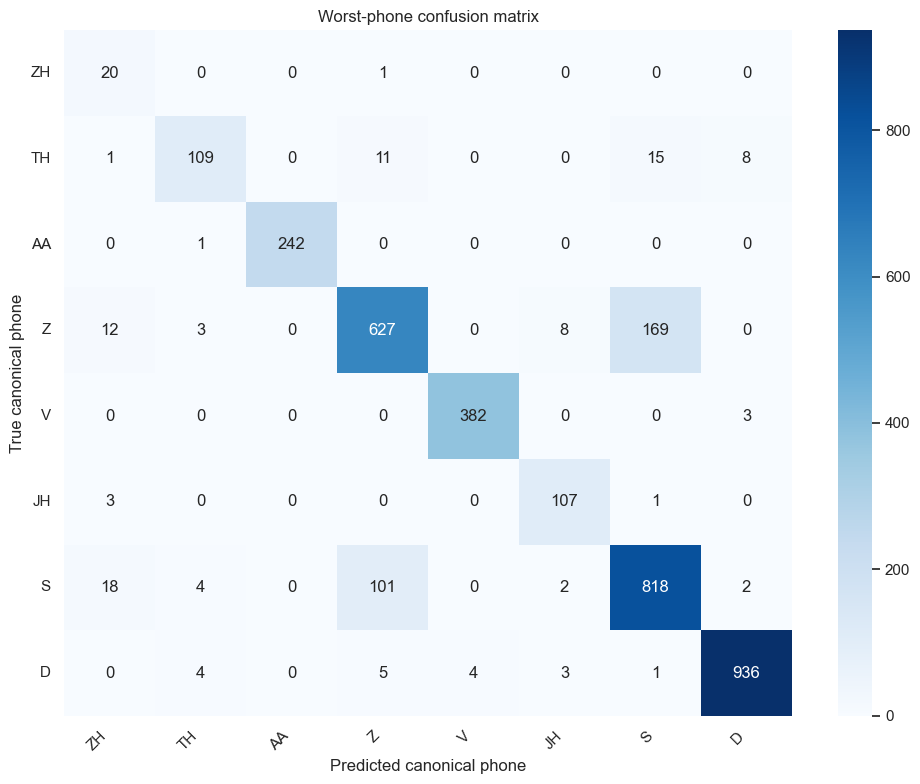

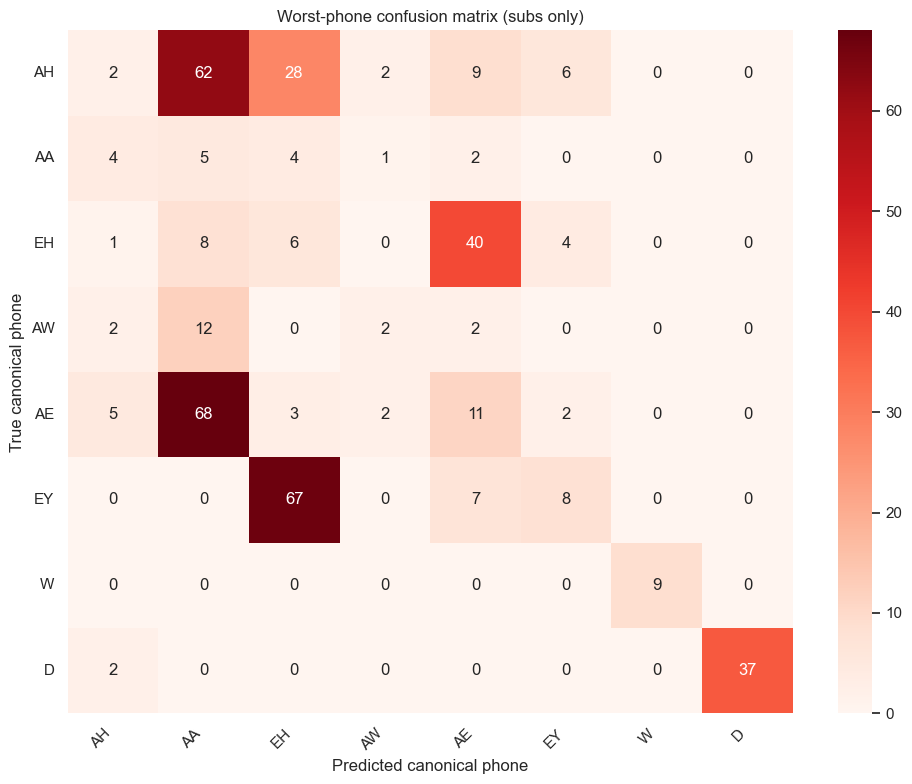

In [39]:
res = run_experiment(
    dfphones=df_phones,
    featmap=feat_map,
    window_size=1,
    use_feat_vectors=False,
    include_duration=False,
    random_state=42,
)

show_experiment_summary(res)
plot_worst_confusion(res, substitutions_only=False)
plot_worst_confusion(res, substitutions_only=True)

Running ablation experiments: 100%|██████████| 10/10 [12:50<00:00, 77.00s/it] 


,window_size,use_feat_vectors,include_duration,n_train,n_test,accuracy,top3_accuracy,macro_f1,weighted_f1,c_n,...,s_top3,s_macro_f1,d_n,d_acc,d_top3,d_macro_f1,a_n,a_acc,a_top3,a_macro_f1
0,0,False,False,104482,27445,0.852104,0.964365,0.834453,0.850027,23534,...,0.836250,0.127909,515,0.000000,0.456311,0.000000,196,0.000000,0.112245,0.000000
1,1,False,False,104482,27445,0.895646,0.974276,0.874445,0.896738,23534,...,0.880313,0.263120,515,0.341748,0.664078,0.135247,196,0.020408,0.270408,0.040000
2,2,False,False,104482,27445,0.909164,0.976025,0.895473,0.909993,23534,...,0.888125,0.348931,515,0.417476,0.724272,0.180147,196,0.020408,0.239796,0.040000
3,3,False,False,104482,27445,0.913390,0.977300,0.904238,0.914036,23534,...,0.896563,0.388983,515,0.433010,0.726214,0.199097,196,0.015306,0.265306,0.030151
4,4,False,False,104482,27445,0.916852,0.978175,0.908694,0.917370,23534,...,0.902500,0.404832,515,0.466019,0.747573,0.259486,196,0.010204,0.270408,0.020202
5,0,True,False,104482,27445,0.852104,0.964292,0.834453,0.850027,23534,...,0.836250,0.127909,515,0.000000,0.456311,0.000000,196,0.000000,0.102041,0.000000
6,1,True,False,104482,27445,0.895026,0.973729,0.873060,0.896242,23534,...,0.879687,0.280827,515,0.349515,0.658252,0.128249,196,0.010204,0.260204,0.020202
7,2,True,False,104482,27445,0.909091,0.975733,0.896030,0.909792,23534,...,0.887813,0.374087,515,0.427184,0.706796,0.181567,196,0.015306,0.290816,0.030151
8,3,True,False,104482,27445,0.913463,0.978065,0.904647,0.913928,23534,...,0.900937,0.422144,515,0.452427,0.730097,0.215923,196,0.020408,0.331633,0.040000
9,4,True,False,104482,27445,0.914083,0.978867,0.904971,0.914545,23534,...,0.906875,0.437048,515,0.458252,0.741748,0.222556,196,0.020408,0.346939,0.040000


,window_size,use_feat_vectors,accuracy,macro_f1,s_acc,d_acc,a_acc
9,4,True,0.914083,0.904971,0.583750,0.458252,0.020408
8,3,True,0.913463,0.904647,0.566250,0.452427,0.020408
4,4,False,0.916852,0.908694,0.560937,0.466019,0.010204
3,3,False,0.913390,0.904238,0.544063,0.433010,0.015306
7,2,True,0.909091,0.896030,0.521875,0.427184,0.015306
2,2,False,0.909164,0.895473,0.503437,0.417476,0.020408
6,1,True,0.895026,0.873060,0.415625,0.349515,0.010204
1,1,False,0.895646,0.874445,0.398125,0.341748,0.020408
0,0,False,0.852104,0.834453,0.132188,0.000000,0.000000
5,0,True,0.852104,0.834453,0.132188,0.000000,0.000000


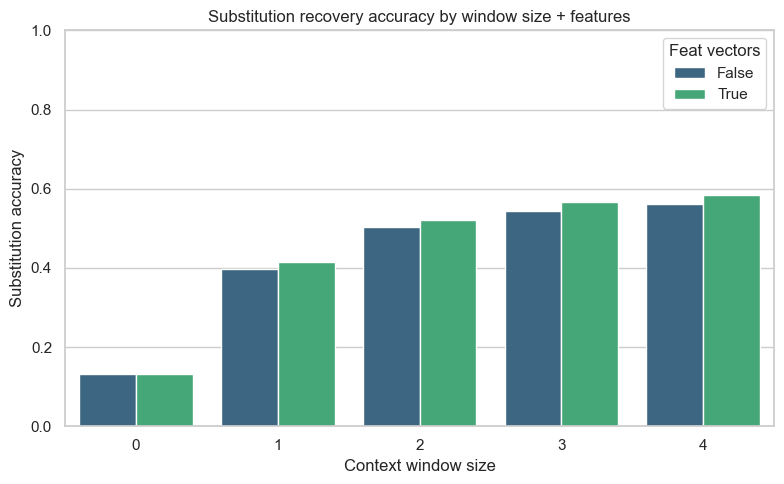

In [43]:
from itertools import product as combinations

ablation_rows = []
all_results = {}

for (window_size, use_feat_vectors) in tqdm(list(combinations([0, 1, 2, 3, 4], [False, True])), desc="Running ablation experiments"):
        key = f"w{window_size}_feat{int(use_feat_vectors)}"
        res = run_experiment(
            dfphones=df_phones,
            featmap=feat_map,
            window_size=window_size,
            use_feat_vectors=use_feat_vectors,
            include_duration=False,
            random_state=42,
        )
        all_results[key] = res

        row = dict(res["overall_metrics"])
        ts = res["type_summary"].set_index("orig_type")
        for t in ["c", "s", "d", "a"]:
            if t in ts.index:
                row[f"{t}_n"] = ts.loc[t, "n"]
                row[f"{t}_acc"] = ts.loc[t, "accuracy"]
                row[f"{t}_top3"] = ts.loc[t, "top3_accuracy"]
                row[f"{t}_macro_f1"] = ts.loc[t, "macro_f1"]
        ablation_rows.append(row)

ablation_df = pd.DataFrame(ablation_rows).sort_values(
    ["use_feat_vectors", "window_size"]
).reset_index(drop=True)

display(ablation_df)
display(
    ablation_df[
        ["window_size", "use_feat_vectors", "accuracy", "macro_f1", "s_acc", "d_acc", "a_acc"]
    ].sort_values(["s_acc", "d_acc", "a_acc"], ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=ablation_df,
    x="window_size",
    y="s_acc",
    hue="use_feat_vectors",
    palette="viridis"
)
plt.title("Substitution recovery accuracy by window size + features")
plt.ylabel("Substitution accuracy")
plt.xlabel("Context window size")
plt.legend(title="Feat vectors")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()